# L2 — Joint tokenizer

One SentencePiece model over **both** languages, so Latin and English index into the same vocabulary. That is what lets the tied embedding serve encoder and decoder alike, and the two share an alphabet and a large amount of word stock.

**8,000 pieces, not 32,000.** At ~94k sentence pairs a 32k vocabulary means most subwords are seen a handful of times — the embedding table becomes untrainable and it is itself a cause of overfitting. Small vocabularies are standard practice in low-resource NMT for exactly this reason.

In [1]:
import os, sys

for candidate in (os.getcwd(), os.path.dirname(os.getcwd())):
    if os.path.isdir(os.path.join(candidate, "src")):
        ROOT = candidate
        sys.path.insert(0, ROOT)
        break

from src.dataset import load_split
from src.spm_tokenizer import SPMTokenizer

DATA = os.path.join(ROOT, "data")
MODEL_PREFIX = os.path.join(DATA, "spm8k")
VOCAB_SIZE = 8000

train_la, train_en = load_split(DATA, "train")
valid_la, valid_en = load_split(DATA, "valid")
test_la, test_en = load_split(DATA, "test")

print(f"train {len(train_la):,} | valid {len(valid_la):,} | test {len(test_la):,}")

train 94,099 | valid 3,003 | test 3,003


## Train

Both training files go in together. `character_coverage=1.0` because both languages use the Latin alphabet — there is no long tail of rare glyphs to trade away, unlike Chinese or Malayalam.

Only the four specials from `config.py` are reserved: `<pad> <sos> <eos> <unk>` at ids 0–3.

In [2]:
tokenizer = SPMTokenizer.train(
    [os.path.join(DATA, "train.la"), os.path.join(DATA, "train.en")],
    MODEL_PREFIX,
    vocab_size=VOCAB_SIZE,
    character_coverage=1.0,
)

print("vocab:", len(tokenizer))
print("specials:", [tokenizer.sp.id_to_piece(i) for i in range(4)])

vocab: 8000
specials: ['<pad>', '<s>', '</s>', '<unk>']


## Gate 1 — round-trip

Encoding then decoding must return the original text exactly. If it does not, every BLEU score after this point is measured against subtly different text than the references.

In [3]:
def round_trip_failures(lines):
    return [l for l in lines if tokenizer.decode(tokenizer.encode(l)) != l]

for name, lines in [("test.la", test_la), ("test.en", test_en),
                    ("valid.la", valid_la), ("valid.en", valid_en)]:
    bad = round_trip_failures(lines)
    print(f"  {name:<9} {len(bad)} failures / {len(lines):,}")
    for l in bad[:2]:
        print("      orig:", repr(l[:70]))
        print("      back:", repr(tokenizer.decode(tokenizer.encode(l))[:70]))

  test.la   0 failures / 3,003
  test.en   0 failures / 3,003
  valid.la  0 failures / 3,003
  valid.en  0 failures / 3,003


## Gate 2 — unknown tokens and fertility

`<unk>` should be ~0: subwords can spell anything.

**Fertility** is subword pieces per whitespace word. Expect Latin to run higher than English — Latin packs case, number and gender into a single inflected word where English spreads them across several. Above ~2.0 on either side means the vocabulary is too small.

In [4]:
from src.config import UNK_IDX

def stats(lines):
    pieces = words = unk = 0
    for l in lines:
        ids = tokenizer.encode(l)
        pieces += len(ids)
        words += len(l.split())
        unk += sum(i == UNK_IDX for i in ids)
    return unk / max(pieces, 1), pieces / max(words, 1)

print(f"{'corpus':<10} {'<unk>':>8} {'fertility':>10}")
for name, lines in [("train.la", train_la), ("train.en", train_en),
                    ("test.la", test_la), ("test.en", test_en)]:
    u, f = stats(lines)
    print(f"  {name:<8} {u:>8.4%} {f:>10.2f}")

corpus        <unk>  fertility
  train.la  0.0000%       1.84
  train.en  0.0000%       1.39
  test.la   0.0000%       1.84
  test.en   0.0000%       1.39


## What it learned

Latin inflection is the interesting case. A noun carries its case in the ending, so the tokenizer has to decide whether to keep whole forms or split off suffixes.

In [5]:
pairs = [
    ("dominus", "dominum"), ("dominus", "domini"),      # nominative / accusative / genitive
    ("ambulabat", "ambulare"), ("amor", "amoris"),
    ("rex", "regis"), ("bellum", "belli"),
]
for a, b in pairs:
    print(f"  {a:<11} {tokenizer.sp.encode(a, out_type=str)}")
    print(f"  {b:<11} {tokenizer.sp.encode(b, out_type=str)}")
    print()

print("English:")
for w in ["walked", "kingdom", "translation", "Jerusalem"]:
    print(f"  {w:<12} {tokenizer.sp.encode(w, out_type=str)}")

  dominus     ['▁dominus']
  dominum     ['▁dominum']

  dominus     ['▁dominus']
  domini      ['▁domini']

  ambulabat   ['▁ambula', 'bat']
  ambulare    ['▁ambula', 're']

  amor        ['▁amor']
  amoris      ['▁amor', 'is']

  rex         ['▁rex']
  regis       ['▁regis']

  bellum      ['▁bellum']
  belli       ['▁belli']

English:
  walked       ['▁walk', 'ed']
  kingdom      ['▁kingdom']
  translation  ['▁trans', 'la', 'tion']
  Jerusalem    ['▁Jerusalem']


## Sequence lengths

This sets `max_len` for training. Truncating at the wrong point either wastes compute on padding or silently cuts sentences off — and a cut-off target with no `<eos>` teaches the model not to stop.

           mean   p50   p95   p99    max
  Latin    38.4    31    90   131    372
  English   46.8    39   107   158    504
  max_len  64: keeps 79.74% of pairs untruncated
  max_len 128: keeps 97.44% of pairs untruncated
  max_len 192: keeps 99.66% of pairs untruncated
  max_len 256: keeps 99.94% of pairs untruncated


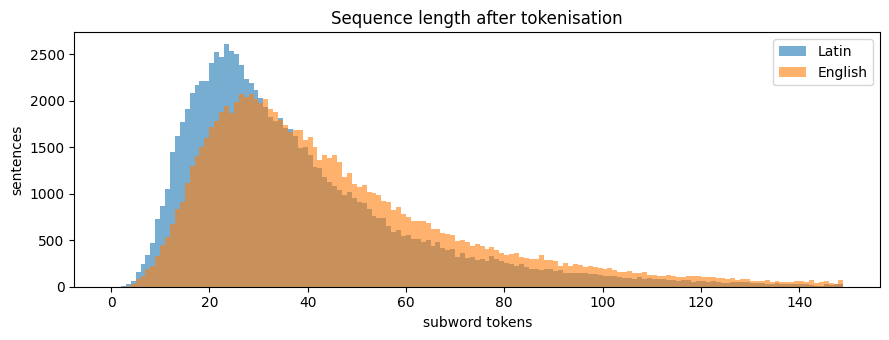

In [6]:
import matplotlib.pyplot as plt
%matplotlib inline

la_len = [len(tokenizer.encode(l)) for l in train_la]
en_len = [len(tokenizer.encode(l)) for l in train_en]

def pct(xs, p):
    return sorted(xs)[int(len(xs) * p)]

print(f"{'':<8} {'mean':>6} {'p50':>5} {'p95':>5} {'p99':>5} {'max':>6}")
for name, xs in (("Latin", la_len), ("English", en_len)):
    print(f"  {name:<6} {sum(xs)/len(xs):>6.1f} {pct(xs,.5):>5} {pct(xs,.95):>5} "
          f"{pct(xs,.99):>5} {max(xs):>6}")

for cap in (64, 128, 192, 256):
    kept = sum(1 for a, b in zip(la_len, en_len) if a <= cap and b <= cap)
    print(f"  max_len {cap:>3}: keeps {kept/len(la_len):.2%} of pairs untruncated")

plt.figure(figsize=(9, 3.5))
plt.hist(la_len, bins=range(0, 150), alpha=0.6, label="Latin")
plt.hist(en_len, bins=range(0, 150), alpha=0.6, label="English")
plt.xlabel("subword tokens"); plt.ylabel("sentences"); plt.legend()
plt.title("Sequence length after tokenisation")
plt.tight_layout(); plt.show()

## Verdict

In [7]:
fail = sum(len(round_trip_failures(l)) for l in (test_la, test_en, valid_la, valid_en))
u_la, f_la = stats(test_la)
u_en, f_en = stats(test_en)

ok = fail == 0 and u_la < 0.001 and u_en < 0.001 and f_la < 2.0 and f_en < 2.0
print(f"round-trip failures {fail} | unk la {u_la:.4%} en {u_en:.4%} "
      f"| fertility la {f_la:.2f} en {f_en:.2f}")
print("\nGATE:", "PASS" if ok else "FAIL")
print(f"\nsaved {MODEL_PREFIX}.model")

round-trip failures 0 | unk la 0.0000% en 0.0000% | fertility la 1.84 en 1.39

GATE: PASS

saved c:\Games\Codes\Python\Projects\2.transformer-from-scratch\data\spm8k.model


## Done

`data/spm8k.model` — a joint 8,000-piece vocabulary over Latin and English.

Next: **L3**, training. The vocabulary size fixes the embedding table, so the model config follows from this: d_model 384, 4+4 layers, ~20M parameters.